# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [13]:
# mostrar las primeras 5 filas de plans
(plans.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [12]:
# mostrar las primeras 5 filas de users
(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [11]:
# mostrar las primeras 5 filas de usage
(usage.head())

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [14]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [15]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [16]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [17]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [19]:
# cantidad de nulos para users
print(users.isnull().sum())

print(users.isnull().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [20]:
# cantidad de nulos para usage
print(usage.isnull().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


**COMENTARIO**
- Diagnóstico (users)
Columna: city 11.7% de nulos:
Tiene una proporción moderada (aprox. 1 de cada 10 usuarios).
- Acción: Investigar e Imputar. Al ser un porcentaje bajo (11%), eliminar estas filas sería perder mucha información; se recomienda intentar recuperar la ciudad mediante otros datos (como el prefijo telefónico) o marcar como "Desconocida".

Columna churn_date (88.3% de nulos):
- Supera el umbral del 80%, pero en este contexto específico tiene un significado de negocio.
- Acción: Mantener como Nulo. En este caso, el nulo no es un error, sino que indica que el usuario sigue activo (no tiene fecha de baja), por lo que no debe eliminarse ni imputarse con fechas aleatorias.

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [35]:
# explorar columnas numéricas de users
print(users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- COMENTARIO
- La columna `user_id` solo se tomará en cuenta como identificador de usuario y no como magnitud entonces no es necesario analizar los datos numéricos.
- La columna `age` El valor mínimo de −999 es un error evidente. Esto está modificando la media hacia abajo (33.7), mientras que la mediana (47.0) nos da una visión mucho más realista de la edad central del grupo.

Acción: Se debe limpiar esta columna, filtrar los valores negativos o imputarlos con la mediana (47) para que no sesguen los análisis futuros

In [36]:
# explorar columnas numéricas de usage
print(usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- **COMENTARIO**
- Las columnas `id` y `user_id` No tienen valor estadístico, solo sirve para distinguir cada usuario.
- La columna duración la media es de 5.2 minutos, pero la mediana es de 3.5. Esta diferencia, sumada al valor máximo de 120 minutos, indica que hay algunas llamadas muy largas que están "desviando" el promedio hacia arriba.
- la columna length parece tener outliers extremos. El máximo es 1,490, mientras que el 75% de los datos llega apenas a 64.

In [40]:

# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']]

print (columnas_user.nunique())
print(columnas_user.value_counts())



city    7
plan    2
dtype: int64
city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64


- **COMENTARIO**
- La columna `city` Se registran 7 valores únicos, pero uno de ellos es el carácter ?.
- La columna `plan` Solo existen 2 categorías (Basico y Premium).

In [42]:
# explorar columna categórica de usage
usage['type'] # completa el código
print("Valores únicos en 'type'")
print(usage['type'].unique())

print("\n Conteo de registros por tipo ")
print(usage['type'].value_counts())

Valores únicos en 'type'
['call' 'text']

 Conteo de registros por tipo 
text    22092
call    17908
Name: type, dtype: int64


- **COMENTARIO**
- La columna `type` El dataset está perfectamente dividido en dos tipos de interacciones: text (mensajes) y call (llamadas), con una tendencia mayor al uso de mensajes, no muy marcada.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

-COMENTARIO:
**Diagnóstico de Valores Inválidos y Sentinels**:
- **Columna "age" (Valor -999):**

**Qué veo:** Se detectó un valor mínimo de −999, el cual es un valor "sentinel" que puede indicar valores de datos faltantes o errores de captura. Esto está sesgando la media de edad hacia abajo (33.7 años).

**Acción recomendada:** Reemplazar los valores −999 por la mediana (47 años) o la moda, para mantener la integridad de la distribución sin perder esos registros.

- **Columna "city" (Valor ?):**

**Qué veo:** Se identificaron 96 registros donde la ciudad está marcada con un signo de interrogación (?). Muestra datos desconocidos.

**Acción recomendada:** Estandarizar estos valores cambiándolos a "Unknown" o "Desconocido" para que el análisis por ciudad sea más profesional y no se mezcle con datos válidos.

**Columna duration y length (Valor 0):**

**Qué veo:** Existen registros con valor 0 en ambas columnas. 

**Acción recomendada:** Dependiendo del objetivo del negocio, si vamos a cobrar por minuto, estos valores de 0 podrían ser ignorados o filtrados, ya que no generan consumo real de minutos o datos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [10]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [11]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')


In [12]:
# Revisar los años presentes en `reg_date` de users
conteo_años_users = users['reg_date'].dt.year.value_counts().sort_index()
print("Distribución de años en reg_date:")
print(conteo_años_users)

Distribución de años en reg_date:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, existe distribución de años del 2022 al 2024 y también registros del 2026, teniendo en cuenta que los datos usados fueron hasta el 2024, existe un erros imposible.

In [14]:
# Revisar los años presentes en `date` de usage
conteo_años_usage = usage['date'].dt.year.value_counts().sort_index()
print("Frecuencia de registros por año (usage):")
print(conteo_años_usage)

Frecuencia de registros por año (usage):
2024.0    39950
Name: date, dtype: int64


En `date`, existen 39950 conteos de registro del año 2024.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

- **COMENTARIO**
Se observan registros que van desde el año 2022 al 2026, sin embargo el dataset tiene registro hasta el año 2024. No se encontraron años negativos, más sin embargo la acción necesaria es filtrar el dataframe y limpiarlo de fechas imposibles como 2026. Podría ser necesario eliminar los datos pero se perdería 40 ingresos a dicha fecha. 


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
users.loc[users['age'] == -999, 'age'] = np.nan
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
print(f"La mediana calculada es: {age_mediana}")
users['age'].describe()


La mediana calculada es: 48.0


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", np.nan)

# Verificar cambios
print(f"Valores nulos en 'city': {users['city'].isna().sum()}")
print("\nPrimeros 5 valores únicos después del cambio:")
print(users['city'].unique()[:5])



Valores nulos en 'city': 565

Primeros 5 valores únicos después del cambio:
['Medellín' nan 'CDMX' 'Bogotá' 'GDL']


In [23]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
nulos_fecha = users['reg_date'].isna().sum()
print(f"Total de fechas fuera de rango convertidas a NaT: {nulos_fecha}")
print("Año máximo registrado:", users['reg_date'].dt.year.max())


Total de fechas fuera de rango convertidas a NaT: 40
Año máximo registrado: 2024.0


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
check_mar_duration = usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()).reset_index()
check_mar_duration.columns = ['type', 'null_count']

# 2. Calcular el total de registros por tipo para sacar el porcentaje
check_mar_duration['total_count'] = usage.groupby('type')['duration'].size().values
check_mar_duration['null_percentage'] = (check_mar_duration['null_count'] / check_mar_duration['total_count']) * 100

print("Análisis de nulos en 'duration' por tipo de uso:")
print(check_mar_duration)

Análisis de nulos en 'duration' por tipo de uso:
   type  null_count  total_count  null_percentage
0  call           0        17908         0.000000
1  text       22076        22092        99.927576


In [25]:
# Verificación MAR en usage (Missing At Random) para length
check_mar_length = usage.groupby('type')['length'].apply(lambda x: x.isna().sum()).reset_index()
check_mar_length.columns = ['type', 'null_count']

# 2. Calcular el total de registros y el porcentaje de nulos por categoría
check_mar_length['total_count'] = usage.groupby('type')['length'].size().values
check_mar_length['null_percentage'] = (check_mar_length['null_count'] / check_mar_length['total_count']) * 100

print("Análisis de nulos en 'length' por tipo de uso:")
print(check_mar_length.sort_values(by='null_percentage', ascending=False))

Análisis de nulos en 'length' por tipo de uso:
   type  null_count  total_count  null_percentage
0  call       17896        17908        99.932991
1  text           0        22092         0.000000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**comentario**
**"duration"**: Tras analizar la distribución de nulos, se observa una correlación centre la variable type y la ausencia de datos en duration:
    **Para call (Llamadas):** El 0% de los registros son nulos. Esto significa que cada vez que hay una llamada, el sistema registra correctamente su duración. Los datos están completos.
    **Para text (Mensajes):** El 99.93% de los registros son nulos. Es evidente que un mensaje de texto no posee la propiedad física de "duración" en tiempo por lo que no hay registro.

    Los datos son MAR (Missing At Random). La falta de información en duration no es accidental ni aleatoria; está explicada enteramente por la variable type. No es que el dato "se haya perdido", es que no existe por definición para esa categoría.

**"lenght"**
    **Para text (Mensajes):** El 0% de los registros son nulos. El sistema captura la longitud de cada mensaje de texto sin excepciones. Esto indica que length es la métrica principal para esta categoría.
    **Para call (Llamadas):** El 99.93% de los registros son nulos. Al igual que los mensajes no tienen "duración", las llamadas de voz no tienen una "longitud" entendida como tamaño de texto.

    Confirmado como MAR (Missing At Random). La ausencia de datos en length está perfectamente explicada por el hecho de que el registro es una llamada (type == 'call').

Acción Recomendada: Conservar los nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [3]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [7]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'cant_mensajes': 'total_mensajes',
    'cant_llamadas': 'total_llamadas',
    'cant_minutos_llamada': 'total_minutos'
})
# observar resultado
usage_agg.head(3)

,user_id,total_mensajes,total_llamadas,total_minutos
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [8]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_mensajes,total_llamadas,total_minutos
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [32]:
# Resumen estadístico de las columnas numéricas
resumen = users.describe()
print("Resumen estadístico de las columnas numéricas:")
print(resumen)


Resumen estadístico de las columnas numéricas:
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    48.136000
std     1154.844867    17.689919
min    10000.000000    18.000000
25%    10999.750000    33.000000
50%    11999.500000    48.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


In [36]:
# Distribución porcentual del tipo de plan
distribucion = plans['plan_name'].value_counts(normalize=True) * 100
print("Distribución porcentual del tipo de plan:")
print(distribucion)

Distribución porcentual del tipo de plan:
Basico     50.0
Premium    50.0
Name: plan_name, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

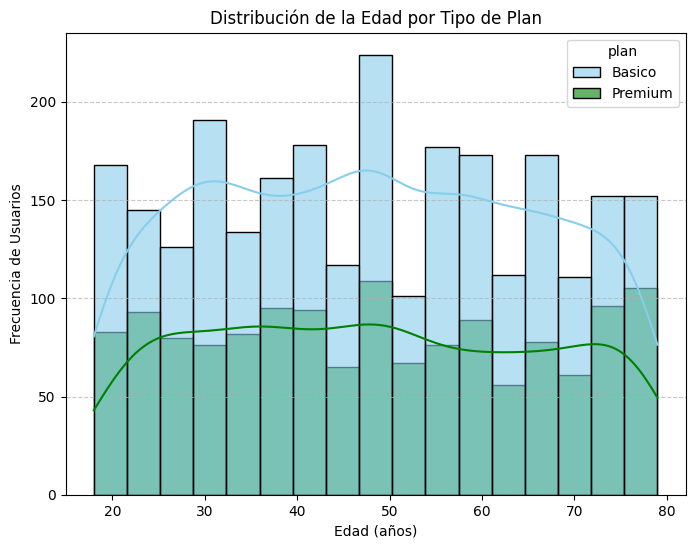

In [58]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(8, 6))

sns.histplot(data=users,  # ✅ Usar users como fuente de datos
             x='age', 
             hue='plan', 
             kde=True, 
             palette=['skyblue', 'green'], 
             alpha=0.6)


plt.title('Distribución de la Edad por Tipo de Plan')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia de Usuarios')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


💡Insights: 
- Distribución Multimodal: No hay una única edad que domine. Se observan varios picos en ambos planes (alrededor de los 30, 50 y 70 años).
- Presencia en Adultos Mayores: Es notable que hay una cantidad considerable de usuarios de entre 70 y 80 años en ambos planes.
  
**Comparación Básico vs. Premium**
    Proporcionalidad: La relación entre usuarios del plan Básico (azul) y Premium (verde) se mantiene relativamente constante a través de todas las edades. No parece haber un "segmento joven" que prefiera abrumadoramente el plan Premium, ni un "segmento mayor" que se quede solo en el Básico.
    
 Pico en los 50s: El punto de mayor adopción para ambos planes parece ocurrir cerca de los 50 años. Podría ser un segmento con mayor estabilidad económica o mayores necesidades de conectividad familiar.

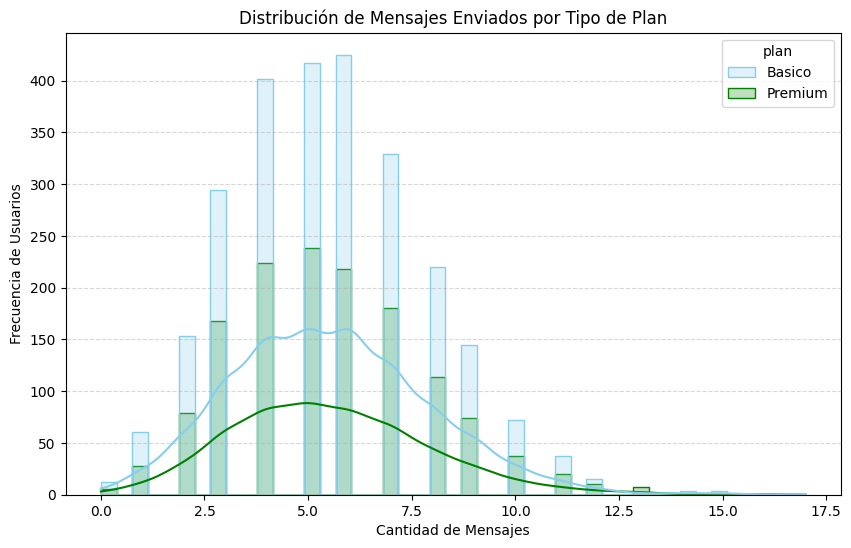

In [48]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, 
             x='total_mensajes', 
             hue='plan', 
             kde=True, 
             palette=['skyblue', 'green'], 
             element="step") # 'step' ayuda a ver mejor el solapamiento

plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia de Usuarios')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

💡Insights: 
- La mayoría de los usuarios, independientemente de su plan, envían entre 5 y 7 mensajes. Este es el punto de mayor frecuencia (la moda).

Similitud entre Planes: el hábito de mensajería no varía drásticamente por tener un plan Premium o Básico.

- El uso de mensajes es bastante bajo en general. Casi nadie envía más de 12.5 mensajes, lo que indica que los usuarios prefieren otros medios.
- Segmentación por Edad: vemos que la edad está distribuida uniformemente, no hay diferencia predominante.
- en su distribución se observa una cola que alarga hacia la derecha mostrando baja frecuencia de usuarios que envían mas de 15 mensajes. 

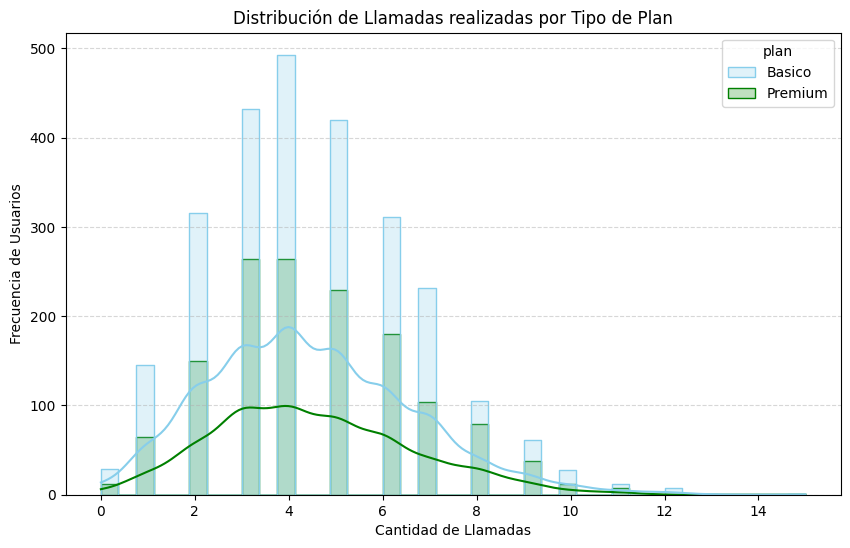

In [50]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, 
             x='total_llamadas', 
             hue='plan', 
             kde=True, 
             palette=['skyblue', 'green'], 
             element="step") # 'step' ayuda a ver mejor el solapamiento

plt.title('Distribución de Llamadas realizadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia de Usuarios')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


💡Insights: 
- Distribución en Similitud en el uso: A pesar de la diferencia en el costo o beneficios de los planes, el comportamiento central es muy parecido. Ambos planes muestran un pico de actividad (moda) entre las 4 y 5 llamadas.

- Concentración: La mayor parte de los usuarios, sin importar el plan, se sitúa en el rango de 3 a 7 llamadas.

- Sesgo a la derecha: Ambas distribuciones tienen una "cola" que se extiende hacia la derecha. Esto significa que hay una pequeña minoría de usuarios que realizan muchas llamadas (más de 10).

- Límites de uso: Se observa que después de las 10 llamadas, la frecuencia de usuarios en ambos planes cae drásticamente, casi desapareciendo después de las 14 llamadas.

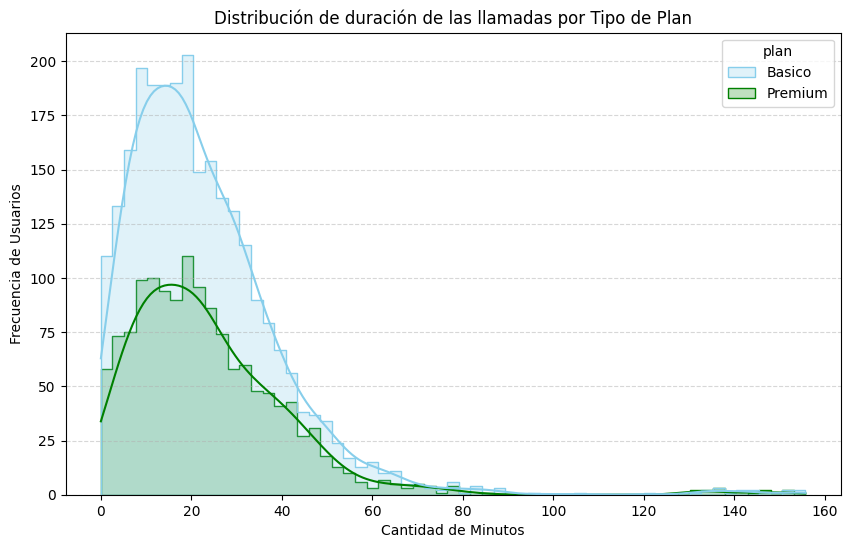

In [51]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, 
             x='total_minutos', 
             hue='plan', 
             kde=True, 
             palette=['skyblue', 'green'], 
             element="step") # 'step' ayuda a ver mejor el solapamiento

plt.title('Distribución de duración de las llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Minutos')
plt.ylabel('Frecuencia de Usuarios')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

💡Insights: 
- Distribución Uniforme: La edad de los usuarios no es un factor determinante para la elección del plan, ya que ambos grupos muestran una distribución relativamente constante entre los 20 y 80 años.
- Segmento Senior: Existe una presencia notable de usuarios mayores de 70 años, lo que sugiere que el servicio tiene una alta penetración en la tercera edad.
- Duración de las Llamadas

    Punto Consumo: La mayor parte de las llamadas duran entre 10 y 20 minutos para ambos tipos de clientes.

    Comportamiento de la Curva: Ambas distribuciones son sesgadas a la derecha; mientras la mayoría hace llamadas breves o medianas, hay una "cola" de usuarios que realizan llamadas de hasta 60 minutos o más.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

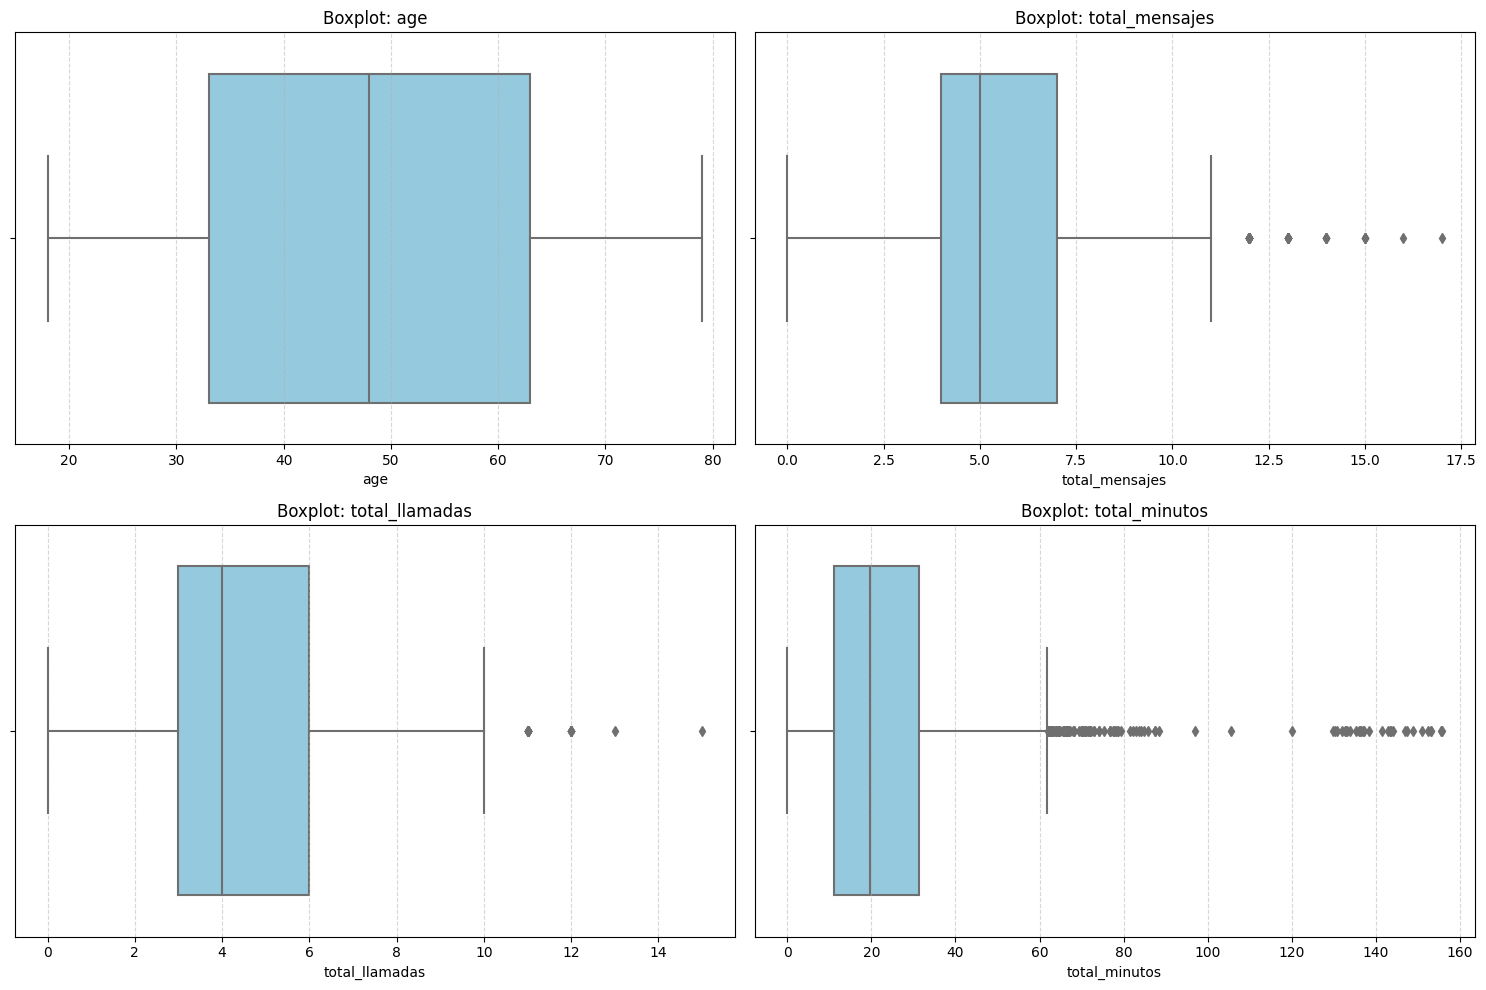

In [62]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'total_mensajes', 'total_llamadas', 'total_minutos']
# Configuración de la figura
plt.figure(figsize=(15, 10))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    # Generamos el boxplot
    sns.boxplot(x=user_profile[col], color='skyblue')
    # Título dinámico según la columna
    plt.title(f'Boxplot: {col}')
    plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

💡Insights: 
- Age: No presenta outliers. Los bigotes cubren todo el rango de datos (aprox. 18 a 80 años) y no hay puntos aislados más allá de ellos.
- cant_mensajes: presenta outliers hacia la drecha que desvian la moda. Se observan varios puntos individuales a la derecha del bigote superior, comenzando aproximadamente después de los 11 mensajes.
- cant_llamadas: Hay puntos aislados (outliers) en el extremo derecho, indicando usuarios que realizan más de 10 llamadas.
- cant_minutos_llamada: presenta outliers extremos hacia la derecha con duración de la llamada mayor a 140 minutos. Es la variable con mayor cantidad de valores atípicos

In [68]:


# Calcular límites con el método IQR
columnas_limites = ['total_mensajes', 'total_llamadas', 'total_minutos']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculamos solo el límite superior (Upper Bound)
    limite_superior = Q3 + 1.5 * IQR

    # Cálculo del límite inferior
    limite_inferior = Q1 - 1.5 * IQR

    
    print(f"\nVariable: {col}")
    print(f"  - Límite Inferior: {limite_inferior:.2f}")
    print(f"  - Límite Superior: {limite_superior:.2f}")






Variable: total_mensajes
  - Límite Inferior: -0.50
  - Límite Superior: 11.50

Variable: total_llamadas
  - Límite Inferior: -1.50
  - Límite Superior: 10.50

Variable: total_minutos
  - Límite Inferior: -19.32
  - Límite Superior: 61.86


In [69]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,total_mensajes,total_llamadas,total_minutos
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

**Análisis y Recomendación**

En total_mensajes y total_llamadas:

        Observación: Los valores máximos (17 mensajes, 15 llamadas) son perfectamente posibles para un cliente real en un mes.

        Decisión: Mantener. Estos outliers representan a los clientes más activos, pero no distorsionan la realidad del negocio de manera absurda.

En total_minutos:

    Observación: Aquí hay una brecha enorme. Mientras que el 75% de los usuarios habla menos de 31 minutos, tenemos casos de 155 minutos.

    Riesgo: Estos valores van a inflar la media hacia arriba, haciendo que el usuario "promedio" parezca que consume más de lo que realmente hace.

    Decisión: Filtrar o Segmentar para realizar un adecuado análisis de promedio de consumo.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [9]:
# Crear columna grupo_uso
# Definimos la función con la lógica de segmentación
def definir_segmento(row):
    llamadas = row['total_llamadas']
    mensajes = row['total_mensajes']
    
    # Condición para Bajo uso
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    # Condición para Uso medio
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    # Para el resto de los casos
    else:
        return 'Alto uso'

# Creamos la columna grupo_uso aplicando la función fila por fila
user_profile['grupo_uso'] = user_profile.apply(definir_segmento, axis=1)

# Mostramos la distribución de los nuevos segmentos
print("Distribución del Grupo de Uso:")
print(user_profile['grupo_uso'].value_counts())

Distribución del Grupo de Uso:
Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


In [10]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_mensajes,total_llamadas,total_minutos,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [11]:
# Crear columna grupo_edad
# Definimos la función para segmentar por edad
def segmentar_edad(age):
    # Condición para Joven
    if age < 30:
        return 'Joven'
    # Condición para Adulto (entre 30 y 59 años)
    elif age < 60:
        return 'Adulto'
    # Condición para Adulto Mayor (60 años o más)
    else:
        return 'Adulto Mayor'

# Aplicamos la función a la columna 'age'
user_profile['grupo_edad'] = user_profile['age'].apply(segmentar_edad)

# Verificamos la distribución de los grupos de edad
print("Distribución por Grupo de Edad:")
print(user_profile['grupo_edad'].value_counts())

Distribución por Grupo de Edad:
Adulto          1963
Adulto Mayor    1222
Joven            815
Name: grupo_edad, dtype: int64


In [12]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_mensajes,total_llamadas,total_minutos,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

Text(0, 0.5, 'Cantidad de Usuarios')

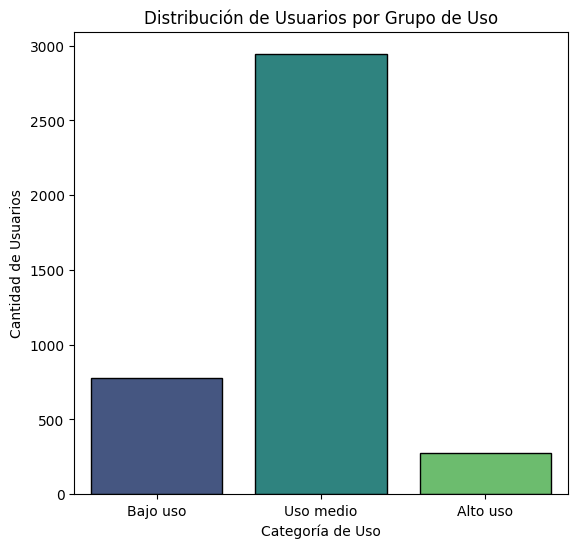

In [24]:
# Visualización de los segmentos por uso
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', 
              order=['Bajo uso', 'Uso medio', 'Alto uso'], edgecolor='black', linewidth=1)
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Categoría de Uso')
plt.ylabel('Cantidad de Usuarios')

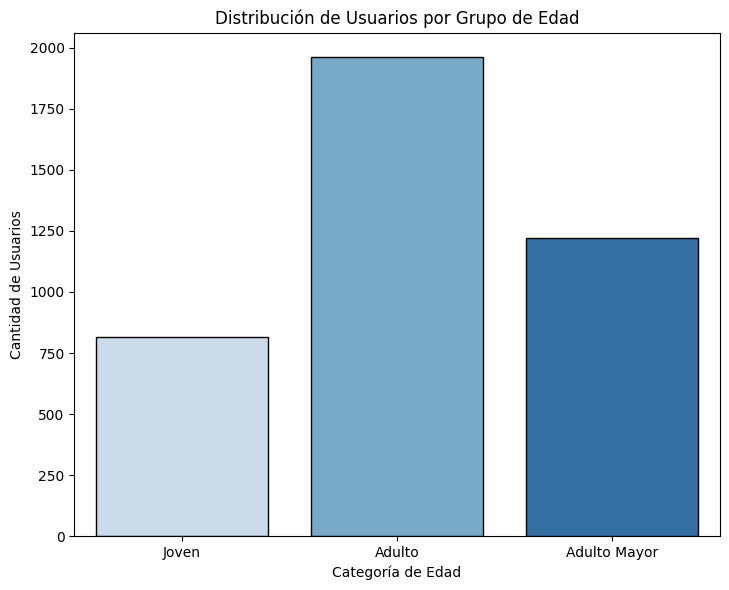

In [22]:
# Visualización de los segmentos por edad
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 2)
sns.countplot(data=user_profile, x='grupo_edad', palette='Blues',
              order=['Joven', 'Adulto', 'Adulto Mayor'],
              edgecolor='black', linewidth=1) 
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Categoría de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.tight_layout()
plt.show()



Paso 7:
Insight Ejecutivo para Stakeholders

🎯 Objetivo: Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

Preguntas a responder:

    ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

    ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

    ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

    ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

    ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ Escribe aquí tu análisis ejecutivo:


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Existencia de valores nulos en city 11.7% de nulos (Tiene una proporción moderada (aprox. 1 de cada 10 usuarios)) y churn_date (más del 80%) pero no es un valor significativo y no podían eliminarse para no perder el rastro de la base total de clientes; en el caso de churn_date, la ausencia de dato simplemente indica que el cliente sigue activo. 
- Se detectaron valores inválidos y setinnels, como edad reemplazando valores negativos por moda.
- Se remplazaron caracteres como “?” en la columna city para mejor análisis.
- Se estandarizó la columna fecha, eliminando valores mposibles como años mayores a 2024.


🔍 **Segmentos por Edad**

Clasificamos a los usuarios en tres grupos demográficos para entender sus patrones generacionales:

    Joven (< 30 años): Un segmento dinámico que, a pesar de las expectativas, muestra un comportamiento de consumo de voz y SMS muy similar al de los adultos, sin picos extremos de diferenciación.

    Adulto (30 a 59 años): El grupo más numeroso de la empresa. Concentra el pico de actividad cerca de los 50 años, siendo el motor principal de tráfico para ConnectaTel.

    Adulto Mayor (≥ 60 años): Un segmento relevante que llega hasta los 80 años. Contrario a los mitos tecnológicos, mantienen una presencia constante en la base de datos y un nivel de uso estable.


📊 **Segmentos por Nivel de Uso**
Segmentación por Nivel de Uso

Basándonos en la actividad mensual de llamadas y mensajes, identificamos tres perfiles distintos:

    Bajo Uso: Clientes que realizan menos de 5 llamadas y envían menos de 5 mensajes. Representan el volumen más alto de la base, indicando un uso de conectividad básica.

    Uso Medio: Usuarios que no superan las 10 llamadas o mensajes. Es un grupo de transición con un comportamiento moderado.

    Alto Uso: Usuarios que superan los umbrales de 10 llamadas o mensajes. Aquí se encuentran los outliers detectados en los boxplots, especialmente en la duración de llamadas, donde algunos alcanzan hasta 155.69 minutos.


➡️ Esto sugiere que existe uniformidad de Planes; se observó que el comportamiento de estos segmentos no varía drásticamente entre el plan Básico y el Premium. Los usuarios de "Alto Uso" están distribuidos en ambos planes, lo que sugiere que el plan Premium no está capturando exclusivamente a los clientes de mayor consumo de voz/SMS.

Estabilidad Demográfica: La edad no es un limitante para el uso del servicio; los "Adultos Mayores" se comportan de manera muy similar a los "Jóvenes" en las variables analizadas (llamadas y mensajes).


💡 **Recomendaciones**
- Reestructuración de la Oferta Comercial

    Diferenciación de Planes: Dado que los usuarios del plan Básico y Premium se comportan de forma casi idéntica en llamadas y mensajes, el valor del plan Premium debe centrarse en datos móviles o servicios exclusivos de valor agregado.

    Paquetes para "Heavy Users": Crear un paquete de "Minutos Ilimitados" dirigido específicamente al segmento de Alto Uso (aquellos que superan los 62 minutos), para evitar que el cobro por excedentes genere insatisfacción y posible fuga de clientes (churn).
  
- Estrategias por Segmento de Edad

    Fidelización del Adulto Mayor: Este segmento es robusto y fiel. Se recomienda lanzar promociones de "Asistencia Técnica Senior" o aplicaciones de salud integradas, ya que usan el servicio de manera constante y estable.

    Captación de Jóvenes: Para el segmento Joven, que actualmente no muestra una diferenciación clara en uso de voz, la estrategia debe virar hacia redes sociales ilimitadas o streaming, que son sus verdaderos motores de consumo.

- Oportunidades de Retención

    Predicción de Abandono: Utilizar la columna churn_date para identificar patrones en clientes que ya se fueron y aplicar campañas de retención preventivas en los clientes activos que muestren una caída repentina en su grupo_uso.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`